In [1]:
import os
import json
import random
import warnings
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import torchvision
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision.ops import nms
import torch.nn.functional as F
from transformers import (
    DeformableDetrImageProcessor,
    DeformableDetrConfig,
    DeformableDetrForObjectDetection,
)
from coco_eval import CocoEvaluator

warnings.filterwarnings("ignore")
print("Torch:", torch.__version__)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Torch: 2.11.0+cu130
Device: cuda


In [2]:
# =========================================================
# 1. Paths and Hyperparameters
# =========================================================

# Data paths (please changeto correct path)
DATA_PATH = "nycu-hw2-data"

TRAIN_DIRECTORY = os.path.join(DATA_PATH, "train")
VAL_DIRECTORY = os.path.join(DATA_PATH, "valid")
TEST_DIRECTORY = os.path.join(DATA_PATH, "test")
TRAIN_ANNOTATION_FILE = os.path.join(DATA_PATH, "train.json")
VAL_ANNOTATION_FILE = os.path.join(DATA_PATH, "valid.json")

# Model checkpoint path (please changeto correct path)
BEST_MODEL_PATH = "./checkpoints_deformable_detr_baby/best_model_by_map.pth"

# Output file
OUTPUT_JSON = "pred.json"

# Image size (must match the training setting)
DATA_SIZE = 256
CHECKPOINT = "SenseTime/deformable-detr"  # Used only to build the processor

# Dataloader settings
BATCH_SIZE = 16
NUM_WORKERS = 0

# Number of samples to visualize
VIS_NUM = 5

# Default inference parameters
# These values can be overwritten after parameter search.
DEFAULT_SCORE_THRESH = 0.4
DEFAULT_IOU_THRESH = 0.5
DEFAULT_TOPK = 50  # Most images contain up to 5 boxes.

In [3]:
# =========================================================
# 2. Image Processor
# =========================================================
image_processor = DeformableDetrImageProcessor.from_pretrained(
    CHECKPOINT,
    size={"shortest_edge": DATA_SIZE, "longest_edge": DATA_SIZE},
)
print(image_processor)
print("Image processor loaded.")

DeformableDetrImageProcessor {
  "do_convert_annotations": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DeformableDetrImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 256,
    "shortest_edge": 256
  }
}

Image processor loaded.


In [4]:
# =========================================================
# 3. Category mapping
# =========================================================
tmp_dataset = torchvision.datasets.CocoDetection(TRAIN_DIRECTORY, TRAIN_ANNOTATION_FILE)
categories = tmp_dataset.coco.cats

original_cat_ids = sorted(categories.keys())
coco_to_model_cat_id = {cat_id: idx for idx, cat_id in enumerate(original_cat_ids)}
model_to_coco_cat_id = {idx: cat_id for cat_id, idx in coco_to_model_cat_id.items()}

id2label = {
    idx: categories[cat_id]["name"] for idx, cat_id in enumerate(original_cat_ids)
}
label2id = {v: k for k, v in id2label.items()}

print("id2label:", id2label)
print("# categories:", len(id2label))

loading annotations into memory...
Done (t=0.52s)
creating index...
index created!
id2label: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}
# categories: 10


In [5]:
# =========================================================
# 4. Load Model (Please to change with the same in training)
# =========================================================
config = DeformableDetrConfig(
    use_timm_backbone=True,
    backbone="resnet50d",
    use_pretrained_backbone=True,
    dilation=True,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    num_queries=50,
    two_stage=True,
    two_stage_num_proposals=50,
    with_box_refine=True,
    num_feature_levels=3,
    encoder_layers=3,
    decoder_layers=3,
    encoder_ffn_dim=512,
    decoder_ffn_dim=512,
    d_model=256,
    auxiliary_loss=True,
    class_cost=2,
    bbox_cost=5,
    giou_cost=2,
    bbox_loss_coefficient=5,
    giou_loss_coefficient=2,
    eos_coefficient=0.05,
)

model = DeformableDetrForObjectDetection(config)
state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

print("Model loaded from:", BEST_MODEL_PATH)

Model loaded from: ./checkpoints_deformable_detr_baby/best_model_by_map.pth


In [6]:
# =========================================================
# 5. COCO evaluator helper
# =========================================================
def prepare_for_coco_detection(predictions, model_to_coco_cat_id):
    coco_results = []
    for image_id, outputs in predictions.items():
        if len(outputs["boxes"]) == 0:
            continue
        boxes = outputs["boxes"].tolist()
        scores = outputs["scores"].tolist()
        labels = outputs["labels"].tolist()
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box
            coco_category_id = model_to_coco_cat_id[int(label)]
            coco_results.append(
                {
                    "image_id": image_id,
                    "category_id": coco_category_id,
                    "bbox": [x1, y1, x2 - x1, y2 - y1],
                    "score": score,
                }
            )
    return coco_results

In [7]:
# =========================================================
# 6. Datasets & Dataloaders
# =========================================================


# Test Dataset
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, image_processor):
        self.image_dir = image_dir
        self.image_processor = image_processor
        self.files = sorted(
            [
                f
                for f in os.listdir(image_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
        )

    def __len__(self):
        return len(self.files)

    def _parse_image_id(self, filename):
        return int(os.path.splitext(filename)[0])

    def __getitem__(self, idx):
        filename = self.files[idx]
        image = np.array(
            Image.open(os.path.join(self.image_dir, filename)).convert("RGB")
        )
        h, w = image.shape[:2]
        encoding = self.image_processor(images=image, return_tensors="pt")
        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "image_id": self._parse_image_id(filename),
            "orig_image": image,
            "orig_size": (h, w),
            "file_name": filename,
        }


# Val Dataset
class ValDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, annotation_file, image_processor):
        self.coco_dataset = torchvision.datasets.CocoDetection(
            image_dir, annotation_file
        )
        self.image_processor = image_processor
        self.image_dir = image_dir

    def __len__(self):
        return len(self.coco_dataset)

    def __getitem__(self, idx):
        image_pil, _ = self.coco_dataset[idx]
        image_id = self.coco_dataset.ids[idx]
        image_np = np.array(image_pil)
        h, w = image_np.shape[:2]
        encoding = self.image_processor(images=image_np, return_tensors="pt")
        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "image_id": image_id,
            "orig_image": image_np,
            "orig_size": (h, w),
        }


def collate_fn_manual_pad(batch):
    pixel_values_list = [x["pixel_values"] for x in batch]

    max_h = max(x.shape[-2] for x in pixel_values_list)
    max_w = max(x.shape[-1] for x in pixel_values_list)

    padded_pixels = []
    pixel_masks = []

    for x in pixel_values_list:
        c, h, w = x.shape
        pad_h = max_h - h
        pad_w = max_w - w

        padded_x = F.pad(x, (0, pad_w, 0, pad_h), value=0.0)
        padded_pixels.append(padded_x)

        # True 表示有效區域，False 表示 padding
        mask = torch.zeros((max_h, max_w), dtype=torch.bool)
        mask[:h, :w] = True
        pixel_masks.append(mask)

    return {
        "pixel_values": torch.stack(padded_pixels),  # [B, C, H, W]
        "pixel_mask": torch.stack(pixel_masks),  # [B, H, W]
        "image_ids": [x["image_id"] for x in batch],
        "orig_images": [x["orig_image"] for x in batch],
        "orig_sizes": [x["orig_size"] for x in batch],
        "file_names": [x.get("file_name", "") for x in batch],
    }


test_dataset = TestDataset(TEST_DIRECTORY, image_processor)
val_dataset = ValDataset(VAL_DIRECTORY, VAL_ANNOTATION_FILE, image_processor)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_manual_pad,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_manual_pad,
    num_workers=NUM_WORKERS,
)

print("Test  size:", len(test_dataset))
print("Val   size:", len(val_dataset))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Test  size: 13068
Val   size: 3340


In [8]:
# =========================================================
# 7. Post-processing Utilities
# =========================================================
def postprocess(result, score_thresh=0.4, iou_thresh=0.5, topk=10):
    boxes = result["boxes"]
    scores = result["scores"]
    labels = result["labels"]

    # 1. Non-maximum suppression (NMS)
    if len(boxes) > 0:
        keep = nms(boxes, scores, iou_threshold=iou_thresh)
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

    # 2. Score threshold filtering
    if len(boxes) > 0:
        keep = scores >= score_thresh
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

    # 3. Keep only the top-k predictions
    if len(boxes) > topk:
        keep = torch.argsort(scores, descending=True)[:topk]
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

    return {
        "boxes": boxes,
        "scores": scores,
        "labels": labels,
    }


def draw_boxes(
    img,
    boxes,
    labels=None,
    scores=None,
    color=(0, 255, 0),
    thickness=2,
):
    img = img.copy()

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

        if labels is not None:
            label_name = id2label.get(int(labels[i]), str(int(labels[i])))
            score_str = f" {scores[i]:.2f}" if scores is not None else ""
            text = f"{label_name}{score_str}"

            cv2.putText(
                img,
                text,
                (x1, max(y1 - 4, 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                color,
                1,
                cv2.LINE_AA,
            )

    return img

In [9]:
# =========================================================
# 8. Validation + COCO mAP
# =========================================================
@torch.no_grad()
def evaluate_with_coco(
    model,
    dataloader,
    dataset,
    device,
    image_processor,
    model_to_coco_cat_id,
    use_amp=False,
):
    model.eval()
    total_loss = 0.0
    total_loss_dict = {}
    evaluator = CocoEvaluator(coco_gt=dataset.coco, iou_types=["bbox"])
    pbar = tqdm(dataloader, desc="Validation", leave=False)

    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs_with_loss = model(
                pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels
            )

        loss = outputs_with_loss.loss
        loss_dict = outputs_with_loss.loss_dict
        total_loss += loss.item()
        for k, v in loss_dict.items():
            total_loss_dict[k] = total_loss_dict.get(k, 0.0) + v.item()

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        orig_target_sizes = torch.stack(
            [target["orig_size"] for target in labels], dim=0
        )
        results = image_processor.post_process_object_detection(
            outputs, threshold=0.0, target_sizes=orig_target_sizes
        )

        predictions = {
            target["image_id"].item(): {
                "boxes": output["boxes"].detach().cpu(),
                "scores": output["scores"].detach().cpu(),
                "labels": output["labels"].detach().cpu(),
            }
            for target, output in zip(labels, results)
        }
        predictions = prepare_for_coco_detection(predictions, model_to_coco_cat_id)
        evaluator.update(predictions)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    avg_loss_dict = {k: v / len(dataloader) for k, v in total_loss_dict.items()}

    evaluator.synchronize_between_processes()
    evaluator.accumulate()
    evaluator.summarize()

    coco_stats = evaluator.coco_eval["bbox"].stats
    metrics = {
        "map": float(coco_stats[0]),
        "map_50": float(coco_stats[1]),
        "map_75": float(coco_stats[2]),
    }
    return avg_loss, avg_loss_dict, metrics

In [10]:
# =========================================================
# 9. Run validation inference once and collect raw predictions
#    Different thresholds can then be applied without re-running inference.
# =========================================================
@torch.no_grad()
def collect_val_raw_predictions(model, loader, image_processor, device):
    model.eval()
    all_raw = {}

    for batch in tqdm(loader, desc="Val inference (raw)"):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        target_sizes = torch.tensor(batch["orig_sizes"], device=device)
        results = image_processor.post_process_object_detection(
            outputs, threshold=0.0, target_sizes=target_sizes
        )

        for img_id, res, orig_size in zip(
            batch["image_ids"], results, batch["orig_sizes"]
        ):
            all_raw[int(img_id)] = {
                "boxes": res["boxes"].cpu(),
                "scores": res["scores"].cpu(),
                "labels": res["labels"].cpu(),
                "orig_size": orig_size,
            }

    return all_raw


val_raw = collect_val_raw_predictions(model, val_loader, image_processor, DEVICE)
print(f"Collected raw predictions for {len(val_raw)} val images.")

Val inference (raw):  14%|█▍        | 30/209 [00:16<01:38,  1.82it/s]


KeyboardInterrupt: 

In [ ]:
# =========================================================
# 10. Search the best score_thresh & iou_thresh（Grid Search）
# =========================================================
val_coco_gt = torchvision.datasets.CocoDetection(
    VAL_DIRECTORY, VAL_ANNOTATION_FILE
).coco

SCORE_CANDIDATES = [0.0, 0.2, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0]
IOU_CANDIDATES = [0.6, 0.7, 0.8, 0.9, 1.0]
TOPK_FIXED = 50

search_results = []

for s_thresh in tqdm(SCORE_CANDIDATES, desc="score_thresh"):
    for iou_thresh in IOU_CANDIDATES:
        evaluator = CocoEvaluator(coco_gt=val_coco_gt, iou_types=["bbox"])
        coco_preds = []

        for img_id, raw in val_raw.items():
            processed = postprocess(
                raw, score_thresh=s_thresh, iou_thresh=iou_thresh, topk=TOPK_FIXED
            )
            for box, score, label in zip(
                processed["boxes"], processed["scores"], processed["labels"]
            ):
                x1, y1, x2, y2 = box.tolist()
                coco_preds.append(
                    {
                        "image_id": img_id,
                        "category_id": int(model_to_coco_cat_id[int(label)]),
                        "bbox": [x1, y1, x2 - x1, y2 - y1],
                        "score": float(score),
                    }
                )

        if len(coco_preds) > 0:
            evaluator.update(coco_preds)
            evaluator.synchronize_between_processes()
            evaluator.accumulate()

            import io, contextlib

            with contextlib.redirect_stdout(io.StringIO()):
                evaluator.summarize()

            map_val = float(evaluator.coco_eval["bbox"].stats[0])
        else:
            map_val = 0.0

        search_results.append((s_thresh, iou_thresh, map_val))

# 排序
search_results.sort(key=lambda x: x[2], reverse=True)

print("\n=== Top 10 parameter combinations ===")
print(f"{'score_thresh':>12}  {'iou_thresh':>10}  {'mAP':>8}")
print("-" * 36)
for s, iou, m in search_results[:10]:
    print(f"{s:>12.2f}  {iou:>10.2f}  {m:>8.4f}")

BEST_SCORE_THRESH, BEST_IOU_THRESH, BEST_MAP = search_results[0]
SECOND_SCORE_THRESH, SECOND_IOU_THRESH, SECOND_MAP = search_results[1]

print(
    f"\nBest   : score={BEST_SCORE_THRESH}, iou={BEST_IOU_THRESH}, mAP={BEST_MAP:.4f}"
)
print(
    f"Second : score={SECOND_SCORE_THRESH}, iou={SECOND_IOU_THRESH}, mAP={SECOND_MAP:.4f}"
)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


score_thresh:   0%|          | 0/13 [00:00<?, ?it/s]

Accumulating evaluation results...
DONE (t=0.53s).
Accumulating evaluation results...
DONE (t=0.62s).
Accumulating evaluation results...
DONE (t=0.83s).
Accumulating evaluation results...
DONE (t=1.10s).
Accumulating evaluation results...


score_thresh:   8%|▊         | 1/13 [00:27<05:35, 27.98s/it]

DONE (t=2.08s).
Accumulating evaluation results...
DONE (t=0.27s).
Accumulating evaluation results...
DONE (t=0.26s).
Accumulating evaluation results...
DONE (t=0.22s).
Accumulating evaluation results...
DONE (t=0.23s).
Accumulating evaluation results...


...

Accumulating evaluation results...
DONE (t=0.09s).
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.04s).


score_thresh:  92%|█████████▏| 12/13 [01:50<00:05,  5.54s/it]

Accumulating evaluation results...
DONE (t=0.05s).


score_thresh: 100%|██████████| 13/13 [01:51<00:00,  8.56s/it]


=== Top 10 parameter combinations ===
score_thresh  iou_thresh       mAP
------------------------------------
        0.00        1.00    0.4624
        0.00        0.90    0.4546
        0.00        0.80    0.4526
        0.00        0.70    0.4488
        0.20        1.00    0.4485
        0.00        0.60    0.4433
        0.30        1.00    0.4400
        0.20        0.90    0.4375
        0.20        0.80    0.4369
        0.35        1.00    0.4368

✅ Best   : score=0.0, iou=1.0, mAP=0.4624
🥈 Second : score=0.0, iou=0.9, mAP=0.4546


In [ ]:
# =========================================================
# 11. Test Inference → pred.json
# =========================================================
@torch.no_grad()
def run_test_inference(
    model,
    loader,
    image_processor,
    score_thresh,
    iou_thresh,
    topk,
    output_json="pred.json",
    device=DEVICE,
):
    model.eval()
    results_json = []

    for batch in tqdm(loader, desc="Test inference"):
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        target_sizes = torch.tensor(batch["orig_sizes"], device=device)
        raw_results = image_processor.post_process_object_detection(
            outputs, threshold=0.0, target_sizes=target_sizes
        )

        for img_id, res in zip(batch["image_ids"], raw_results):
            processed = postprocess(
                res, 
                score_thresh=score_thresh,
                iou_thresh=iou_thresh,
                topk=topk
            )
            for box, score, label in zip(
                processed["boxes"], processed["scores"], processed["labels"]
            ):
                x1, y1, x2, y2 = box.tolist()
                results_json.append(
                    {
                        "image_id": int(img_id),
                        "category_id": int(model_to_coco_cat_id[int(label)]),
                        "bbox": [x1, y1, x2 - x1, y2 - y1],
                        "score": float(score),
                    }
                )

    with open(output_json, "w") as f:
        json.dump(results_json, f)

    print(f"\n Saved → {output_json}")
    print(f"   Total predictions : {len(results_json)}")
    print(f"   score_thresh      : {score_thresh}")
    print(f"   iou_thresh        : {iou_thresh}")
    print(f"   topk              : {topk}")
    return results_json


predictions = run_test_inference(
    model=model,
    loader=test_loader,
    image_processor=image_processor,
    score_thresh=BEST_SCORE_THRESH,
    iou_thresh=BEST_IOU_THRESH,
    topk=TOPK_FIXED,
    output_json=OUTPUT_JSON,
)

Test inference: 100%|██████████| 817/817 [07:38<00:00,  1.78it/s]



✅ Saved → pred.json
   Total predictions : 653400
   score_thresh      : 0.0
   iou_thresh        : 1.0
   topk              : 50


In [ ]:
# =========================================================
# 12. Visualization utility
# =========================================================
@torch.no_grad()
def visualize_4panel(
    dataset,
    model,
    image_processor,
    best_score,
    best_iou,
    second_score,
    second_iou,
    topk=10,
    num=5,
    device=DEVICE,
    seed=42,
):
    model.eval()
    random.seed(seed)
    num = min(num, len(dataset))
    idxs = random.sample(range(len(dataset)), num)

    COLOR_BEST = (34, 197, 94)  # Green
    COLOR_SECOND = (249, 115, 22)  # orange
    COLOR_RAW = (239, 68, 68)  # red

    for idx in idxs:
        item = dataset[idx]
        orig = item["orig_image"].copy()
        h, w = item["orig_size"]
        fname = item.get("file_name", f"idx={idx}")

        pv = item["pixel_values"].unsqueeze(0).to(device)
        outputs = model(pixel_values=pv)

        raw = image_processor.post_process_object_detection(
            outputs, threshold=0.0, target_sizes=torch.tensor([(h, w)], device=device)
        )[0]

        # Pass three filiter
        best = postprocess(raw, score_thresh=best_score, iou_thresh=best_iou, topk=topk)
        second = postprocess(
            raw, score_thresh=second_score, iou_thresh=second_iou, topk=topk
        )

        # raw prediction
        raw_boxes = raw["boxes"].cpu()
        raw_scores = raw["scores"].cpu()
        raw_labels = raw["labels"].cpu()

        # Visualize by boxes
        img_best = draw_boxes(
            orig, best["boxes"], best["labels"], best["scores"], COLOR_BEST, 2
        )
        img_second = draw_boxes(
            orig, second["boxes"], second["labels"], second["scores"], COLOR_SECOND, 2
        )
        img_raw = draw_boxes(orig, raw_boxes, raw_labels, raw_scores, COLOR_RAW, 1)

        # four image
        fig, axes = plt.subplots(1, 4, figsize=(22, 6))
        fig.suptitle(fname, fontsize=13, fontweight="bold")

        axes[0].imshow(orig)
        axes[0].set_title("Original", fontsize=11)
        axes[0].axis("off")

        axes[1].imshow(img_best)
        axes[1].set_title(
            f"Best\nscore≥{best_score}, IoU≤{best_iou}\n"
            f"boxes={len(best['boxes'])}  (mAP={BEST_MAP:.4f})",
            fontsize=10,
            color="green",
        )
        axes[1].axis("off")

        axes[2].imshow(img_second)
        axes[2].set_title(
            f"Second\nscore≥{second_score}, IoU≤{second_iou}\n"
            f"boxes={len(second['boxes'])}  (mAP={SECOND_MAP:.4f})",
            fontsize=10,
            color="darkorange",
        )
        axes[2].axis("off")

        axes[3].imshow(img_raw)
        axes[3].set_title(
            f"All raw (no filter)\nboxes={len(raw_boxes)}", fontsize=10, color="red"
        )
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

        # Console
        print(f"\n{'='*70}")
        print(f"File: {fname}")
        print(
            f"[Best]   score≥{best_score}, IoU≤{best_iou}  → {len(best['boxes'])} boxes"
        )
        for box, sc, lb in zip(best["boxes"], best["scores"], best["labels"]):
            print(
                f"  {id2label.get(int(lb), lb)}  score={sc:.3f}  box={[round(v.item(),1) for v in box]}"
            )
        print(
            f"[Second] score≥{second_score}, IoU≤{second_iou}  → {len(second['boxes'])} boxes"
        )
        for box, sc, lb in zip(second["boxes"], second["scores"], second["labels"]):
            print(
                f"  {id2label.get(int(lb), lb)}  score={sc:.3f}  box={[round(v.item(),1) for v in box]}"
            )

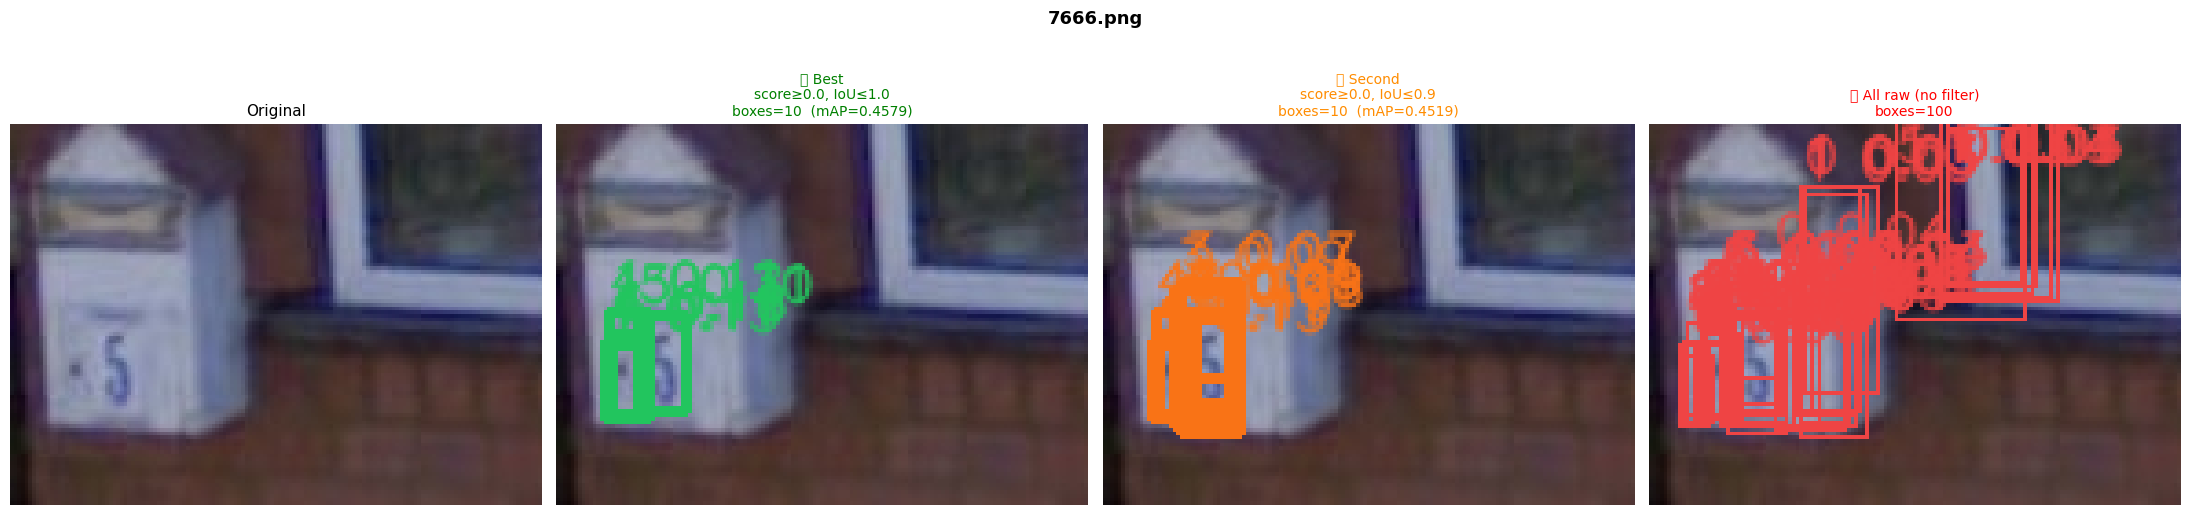


File: 7666.png
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  3  score=0.305  box=[22.4, 52.6, 35.8, 78.6]
  5  score=0.296  box=[22.4, 52.6, 35.8, 78.6]
  4  score=0.193  box=[15.1, 57.4, 25.0, 79.8]
  1  score=0.178  box=[15.1, 57.4, 25.0, 79.8]
  1  score=0.135  box=[13.2, 60.7, 22.4, 80.3]
  4  score=0.122  box=[14.4, 51.1, 25.0, 80.2]
  6  score=0.115  box=[15.1, 57.4, 25.0, 79.8]
  4  score=0.115  box=[13.9, 59.0, 23.4, 79.5]
  1  score=0.113  box=[14.4, 51.1, 25.0, 80.2]
  1  score=0.110  box=[13.9, 59.0, 23.4, 79.5]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  3  score=0.305  box=[22.4, 52.6, 35.8, 78.6]
  4  score=0.193  box=[15.1, 57.4, 25.0, 79.8]
  1  score=0.135  box=[13.2, 60.7, 22.4, 80.3]
  4  score=0.122  box=[14.4, 51.1, 25.0, 80.2]
  4  score=0.115  box=[13.9, 59.0, 23.4, 79.5]
  3  score=0.090  box=[19.2, 45.9, 34.9, 82.5]
  3  score=0.089  box=[23.5, 51.7, 36.5, 76.5]
  3  score=0.075  box=[24.0, 53.0, 34.2, 69.9]
  3  score=0.070  box=[21.3, 43.4, 37.3, 84.0]
  5  score=

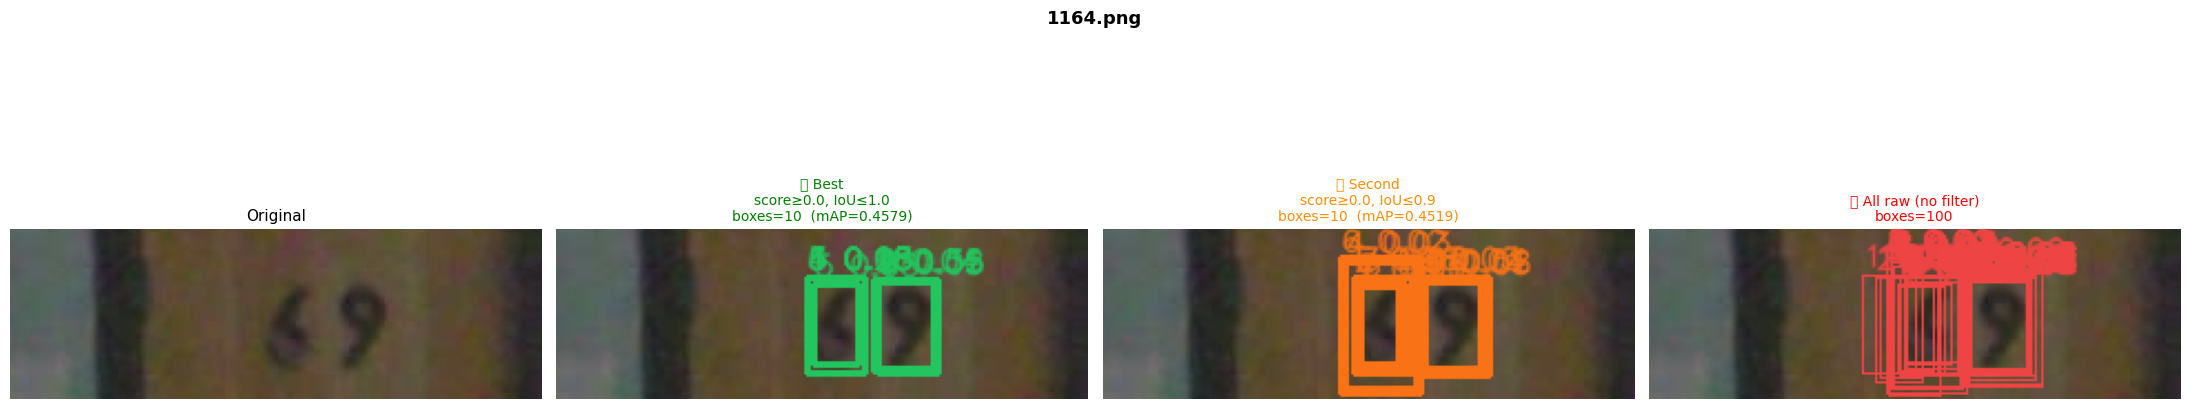


File: 1164.png
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  9  score=0.519  box=[145.3, 23.4, 172.5, 66.0]
  2  score=0.351  box=[145.3, 23.4, 172.5, 66.0]
  5  score=0.282  box=[114.0, 22.4, 139.6, 65.1]
  3  score=0.183  box=[114.0, 22.4, 139.6, 65.1]
  6  score=0.155  box=[114.0, 22.4, 139.6, 65.1]
  4  score=0.127  box=[114.0, 22.4, 139.6, 65.1]
  5  score=0.051  box=[116.1, 25.1, 136.5, 61.9]
  1  score=0.048  box=[114.0, 22.4, 139.6, 65.1]
  9  score=0.048  box=[145.0, 24.2, 170.2, 63.7]
  9  score=0.041  box=[143.6, 23.3, 172.2, 64.0]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  9  score=0.519  box=[145.3, 23.4, 172.5, 66.0]
  5  score=0.282  box=[114.0, 22.4, 139.6, 65.1]
  5  score=0.051  box=[116.1, 25.1, 136.5, 61.9]
  9  score=0.048  box=[145.0, 24.2, 170.2, 63.7]
  9  score=0.041  box=[143.6, 23.3, 172.2, 64.0]
  2  score=0.032  box=[141.0, 22.3, 174.5, 66.3]
  4  score=0.030  box=[113.8, 26.4, 133.6, 65.6]
  4  score=0.028  box=[109.4, 15.8, 141.6, 72.2]
  3  score=0.022  box=

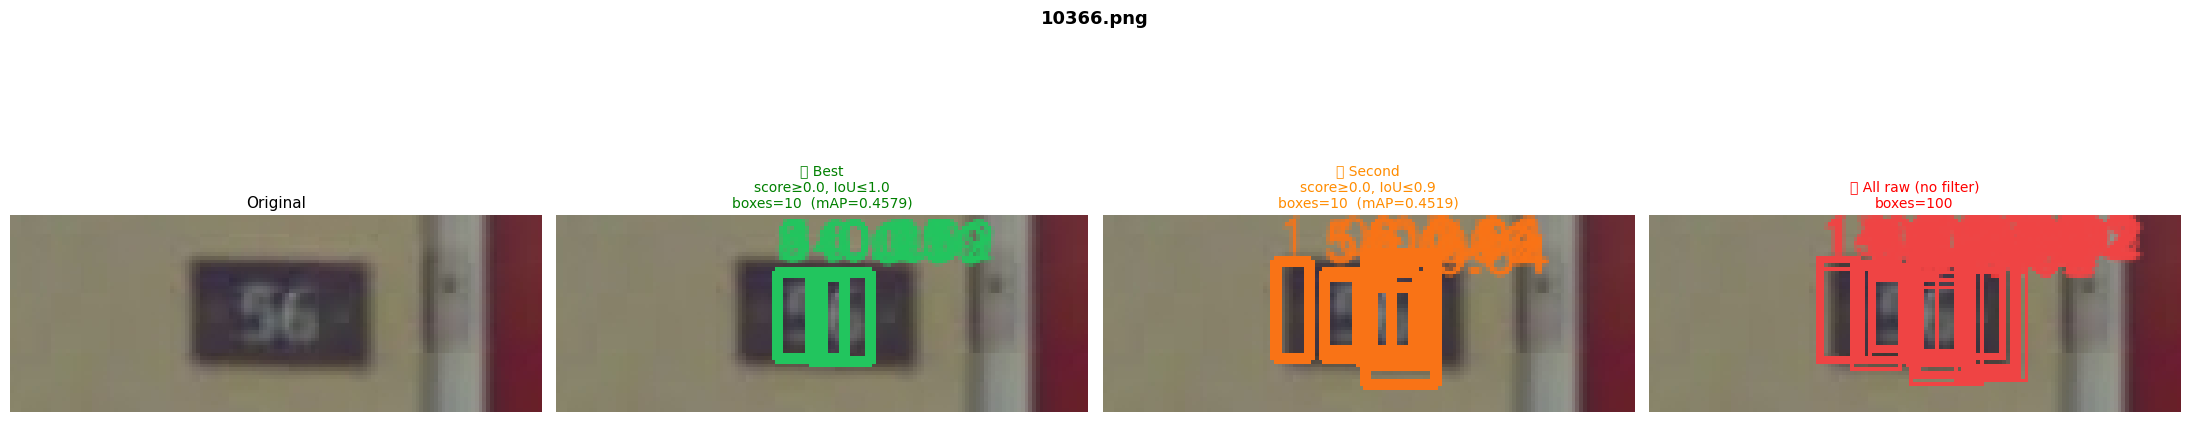


File: 10366.png
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  6  score=0.620  box=[70.7, 15.7, 84.7, 39.0]
  5  score=0.435  box=[59.1, 15.4, 71.6, 38.4]
  3  score=0.253  box=[59.1, 15.4, 71.6, 38.4]
  9  score=0.210  box=[59.1, 15.4, 71.6, 38.4]
  4  score=0.131  box=[59.1, 15.4, 71.6, 38.4]
  8  score=0.130  box=[59.1, 15.4, 71.6, 38.4]
  1  score=0.097  box=[68.1, 16.3, 77.1, 38.4]
  2  score=0.088  box=[59.1, 15.4, 71.6, 38.4]
  4  score=0.086  box=[68.7, 16.0, 78.0, 39.0]
  0  score=0.085  box=[70.7, 15.7, 84.7, 39.0]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  6  score=0.620  box=[70.7, 15.7, 84.7, 39.0]
  5  score=0.435  box=[59.1, 15.4, 71.6, 38.4]
  1  score=0.097  box=[68.1, 16.3, 77.1, 38.4]
  4  score=0.086  box=[68.7, 16.0, 78.0, 39.0]
  6  score=0.058  box=[70.8, 12.4, 87.2, 40.8]
  6  score=0.041  box=[72.9, 19.7, 83.7, 36.7]
  5  score=0.039  box=[59.1, 16.6, 70.6, 36.3]
  6  score=0.036  box=[70.8, 10.7, 90.0, 45.7]
  6  score=0.035  box=[73.0, 19.3, 84.4, 37.4]
  1  score

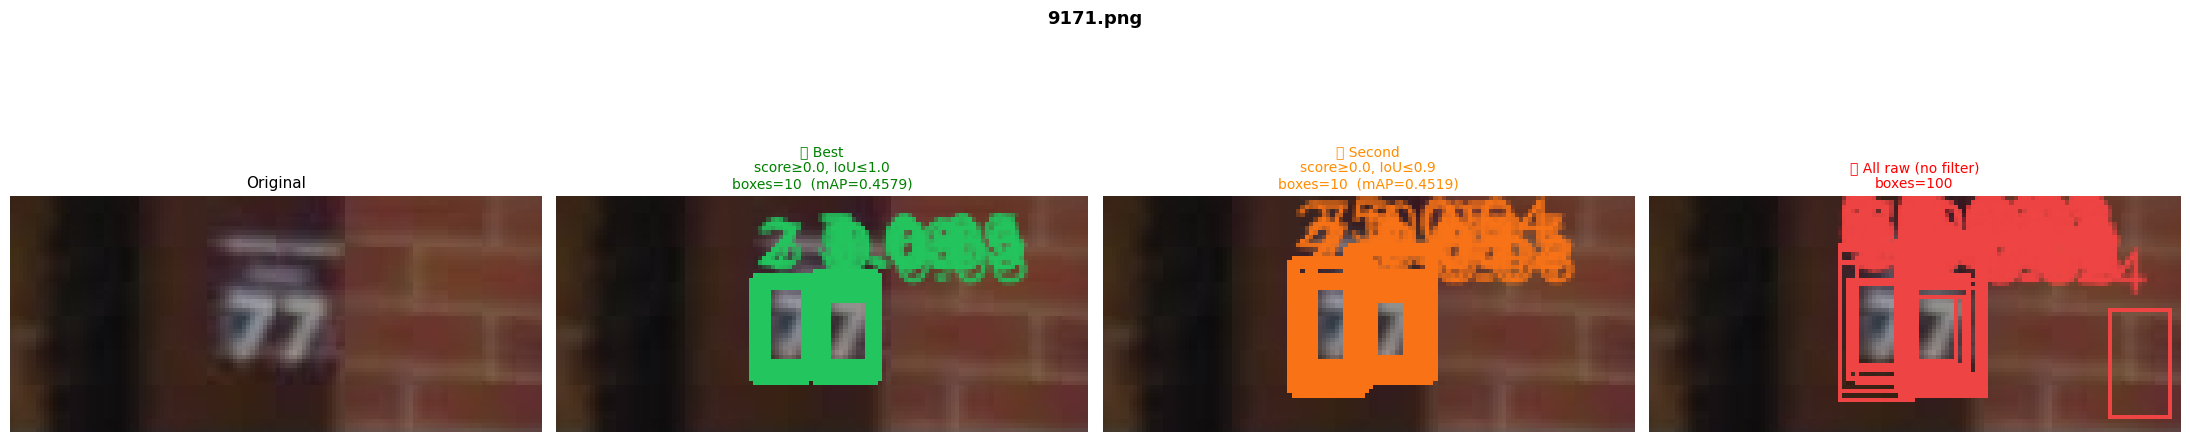


File: 9171.png
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  7  score=0.577  box=[48.7, 20.3, 61.3, 39.8]
  7  score=0.548  box=[61.5, 21.0, 74.1, 40.6]
  7  score=0.225  box=[60.6, 18.2, 74.5, 42.5]
  3  score=0.155  box=[61.5, 21.0, 74.1, 40.6]
  9  score=0.095  box=[61.5, 21.0, 74.1, 40.6]
  3  score=0.093  box=[48.7, 20.3, 61.3, 39.8]
  3  score=0.087  box=[60.6, 18.2, 74.5, 42.5]
  2  score=0.085  box=[46.8, 19.2, 58.7, 42.1]
  7  score=0.085  box=[62.4, 23.4, 73.1, 39.3]
  2  score=0.081  box=[47.8, 19.9, 58.7, 40.7]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  7  score=0.577  box=[48.7, 20.3, 61.3, 39.8]
  7  score=0.548  box=[61.5, 21.0, 74.1, 40.6]
  7  score=0.225  box=[60.6, 18.2, 74.5, 42.5]
  2  score=0.085  box=[46.8, 19.2, 58.7, 42.1]
  7  score=0.085  box=[62.4, 23.4, 73.1, 39.3]
  2  score=0.081  box=[47.8, 19.9, 58.7, 40.7]
  2  score=0.050  box=[44.5, 15.3, 60.3, 46.0]
  7  score=0.047  box=[48.0, 15.4, 62.4, 43.9]
  7  score=0.038  box=[60.8, 23.3, 71.1, 38.6]
  5  score=

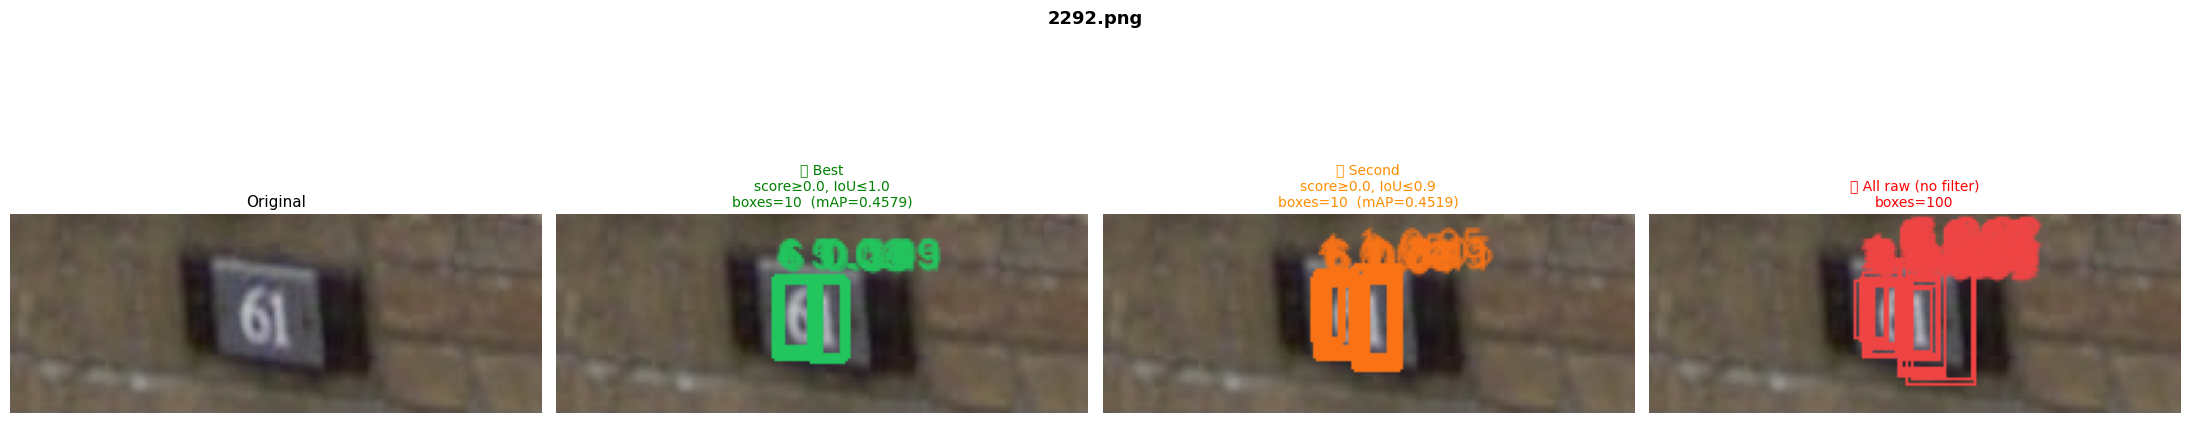


File: 2292.png
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  1  score=0.489  box=[93.8, 23.9, 105.9, 53.1]
  6  score=0.338  box=[80.8, 23.3, 97.0, 52.3]
  6  score=0.326  box=[82.1, 24.9, 96.2, 49.6]
  6  score=0.320  box=[81.3, 24.0, 96.3, 51.2]
  3  score=0.287  box=[93.8, 23.9, 105.9, 53.1]
  6  score=0.276  box=[81.7, 23.1, 96.4, 51.8]
  5  score=0.155  box=[93.8, 23.9, 105.9, 53.1]
  1  score=0.107  box=[95.0, 24.2, 106.0, 52.9]
  4  score=0.094  box=[80.8, 23.3, 97.0, 52.3]
  9  score=0.091  box=[93.8, 23.9, 105.9, 53.1]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  1  score=0.489  box=[93.8, 23.9, 105.9, 53.1]
  6  score=0.338  box=[80.8, 23.3, 97.0, 52.3]
  6  score=0.326  box=[82.1, 24.9, 96.2, 49.6]
  6  score=0.320  box=[81.3, 24.0, 96.3, 51.2]
  1  score=0.107  box=[95.0, 24.2, 106.0, 52.9]
  4  score=0.051  box=[78.0, 21.9, 91.7, 52.6]
  1  score=0.051  box=[95.2, 22.8, 106.9, 53.5]
  1  score=0.046  box=[92.6, 19.2, 108.3, 56.8]
  6  score=0.044  box=[81.4, 25.3, 95.0, 49.8]
  

In [ ]:
# =========================================================
# 13. Visualization in the test data
# =========================================================
visualize_4panel(
    dataset=test_dataset,
    model=model,
    image_processor=image_processor,
    best_score=BEST_SCORE_THRESH,
    best_iou=BEST_IOU_THRESH,
    second_score=SECOND_SCORE_THRESH,
    second_iou=SECOND_IOU_THRESH,
    topk=TOPK_FIXED,
    num=VIS_NUM,
)

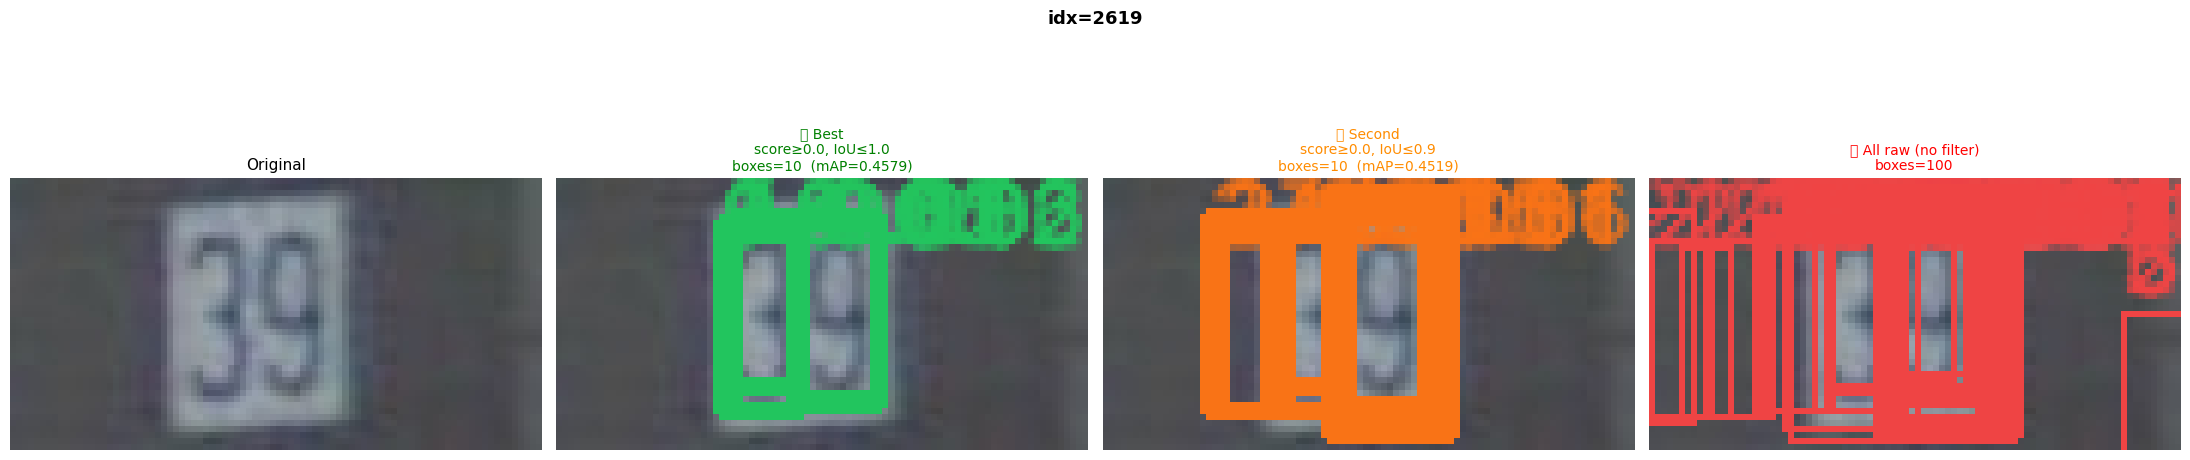


File: idx=2619
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  9  score=0.858  box=[39.8, 6.9, 53.3, 37.5]
  3  score=0.847  box=[27.5, 7.2, 40.4, 38.4]
  4  score=0.026  box=[39.8, 6.9, 53.3, 37.5]
  5  score=0.025  box=[39.8, 6.9, 53.3, 37.5]
  9  score=0.017  box=[39.3, 7.2, 53.1, 36.7]
  9  score=0.015  box=[27.5, 7.2, 40.4, 38.4]
  1  score=0.015  box=[27.5, 7.2, 40.4, 38.4]
  1  score=0.013  box=[29.4, 6.8, 40.3, 38.2]
  1  score=0.012  box=[30.0, 9.3, 39.2, 34.5]
  0  score=0.011  box=[27.5, 7.2, 40.4, 38.4]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  9  score=0.858  box=[39.8, 6.9, 53.3, 37.5]
  3  score=0.847  box=[27.5, 7.2, 40.4, 38.4]
  1  score=0.013  box=[29.4, 6.8, 40.3, 38.2]
  1  score=0.012  box=[30.0, 9.3, 39.2, 34.5]
  9  score=0.011  box=[39.0, 5.1, 55.5, 40.3]
  9  score=0.011  box=[39.1, 5.5, 54.2, 39.2]
  2  score=0.011  box=[19.5, 6.7, 30.0, 38.5]
  2  score=0.010  box=[17.6, 6.9, 29.8, 38.4]
  2  score=0.009  box=[19.9, 8.6, 30.5, 38.9]
  4  score=0.008  box=[38.0, 2

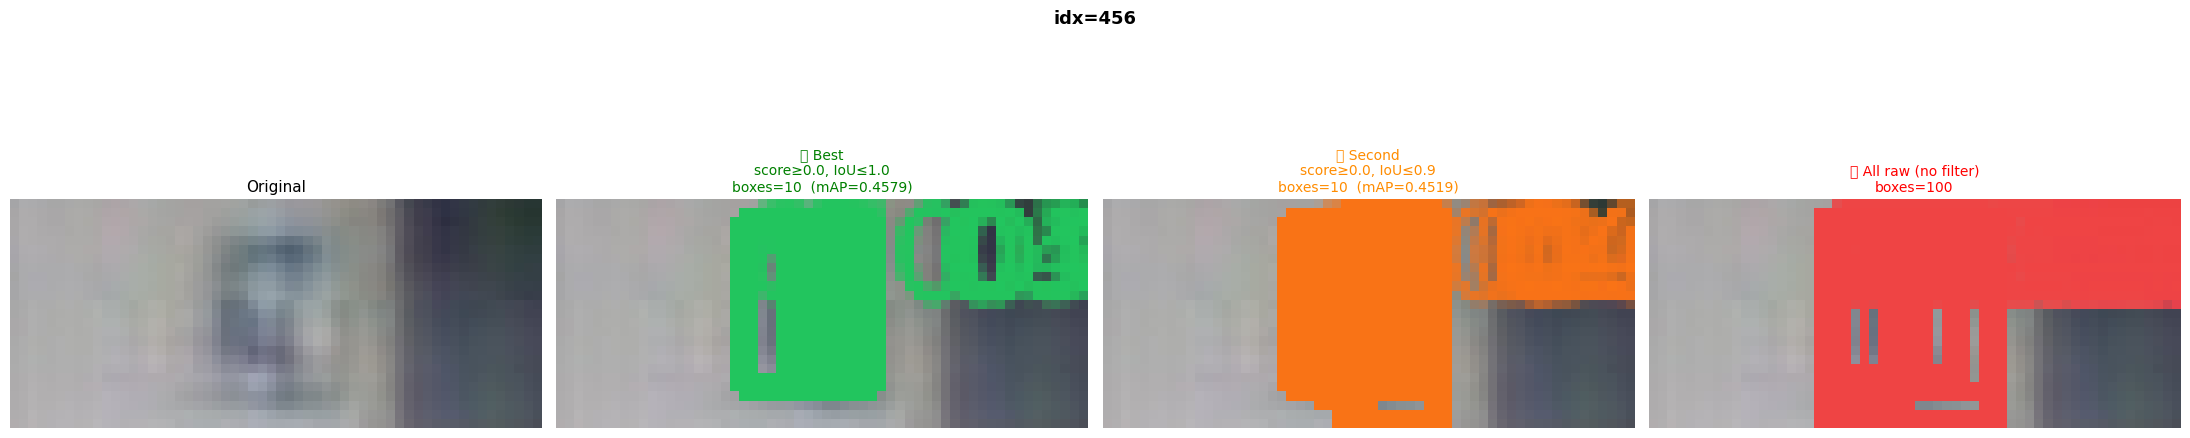


File: idx=456
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  6  score=0.396  box=[20.6, 2.7, 28.2, 20.7]
  7  score=0.376  box=[27.6, 2.8, 34.3, 20.1]
  5  score=0.364  box=[20.6, 2.7, 28.2, 20.7]
  7  score=0.343  box=[27.4, 3.1, 33.5, 18.9]
  8  score=0.151  box=[20.6, 2.7, 28.2, 20.7]
  2  score=0.117  box=[25.1, 3.6, 30.3, 20.1]
  1  score=0.093  box=[25.1, 3.6, 30.3, 20.1]
  2  score=0.081  box=[27.6, 2.8, 34.3, 20.1]
  0  score=0.081  box=[25.1, 3.6, 30.3, 20.1]
  3  score=0.080  box=[25.1, 3.6, 30.3, 20.1]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  6  score=0.396  box=[20.6, 2.7, 28.2, 20.7]
  7  score=0.376  box=[27.6, 2.8, 34.3, 20.1]
  7  score=0.343  box=[27.4, 3.1, 33.5, 18.9]
  2  score=0.117  box=[25.1, 3.6, 30.3, 20.1]
  7  score=0.075  box=[26.8, 3.5, 32.8, 19.6]
  7  score=0.054  box=[28.6, 3.6, 33.4, 19.0]
  1  score=0.053  box=[23.9, 3.3, 29.5, 21.3]
  1  score=0.052  box=[30.7, 4.4, 36.4, 20.8]
  7  score=0.048  box=[29.3, 3.8, 34.2, 19.5]
  7  score=0.046  box=[26.7, 2.

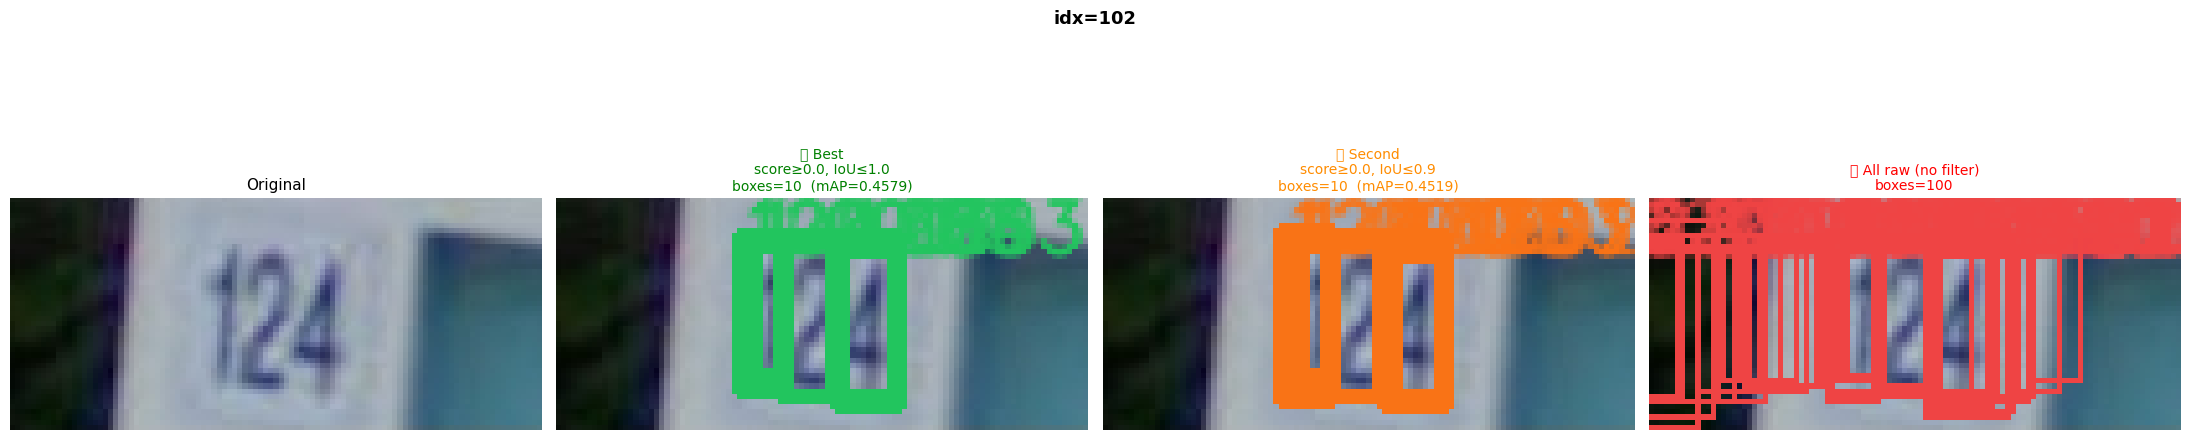


File: idx=102
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  4  score=0.830  box=[54.4, 10.5, 65.4, 38.9]
  2  score=0.754  box=[44.1, 8.5, 55.0, 38.1]
  1  score=0.330  box=[35.9, 7.8, 44.7, 38.0]
  1  score=0.276  box=[35.8, 8.3, 44.5, 37.6]
  1  score=0.073  box=[38.0, 9.5, 44.3, 35.0]
  1  score=0.062  box=[35.8, 8.1, 44.5, 37.8]
  0  score=0.039  box=[44.1, 8.5, 55.0, 38.1]
  1  score=0.033  box=[37.6, 9.0, 44.4, 35.6]
  2  score=0.028  box=[43.6, 8.0, 53.6, 38.2]
  4  score=0.026  box=[54.3, 7.1, 66.9, 40.5]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  4  score=0.830  box=[54.4, 10.5, 65.4, 38.9]
  2  score=0.754  box=[44.1, 8.5, 55.0, 38.1]
  1  score=0.330  box=[35.9, 7.8, 44.7, 38.0]
  1  score=0.073  box=[38.0, 9.5, 44.3, 35.0]
  1  score=0.033  box=[37.6, 9.0, 44.4, 35.6]
  2  score=0.028  box=[43.6, 8.0, 53.6, 38.2]
  4  score=0.026  box=[54.3, 7.1, 66.9, 40.5]
  1  score=0.022  box=[35.0, 6.9, 44.4, 39.4]
  4  score=0.015  box=[56.4, 9.6, 66.3, 38.8]
  2  score=0.014  box=[55.8, 

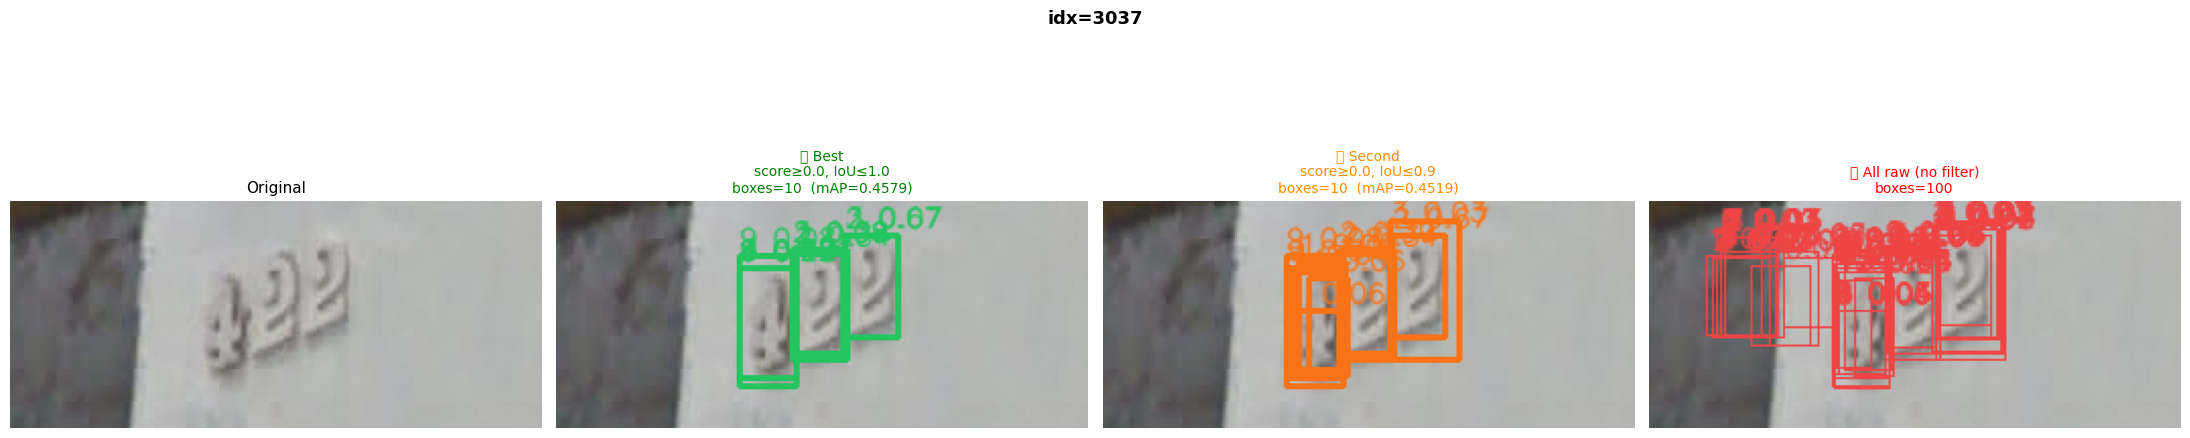


File: idx=3037
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  2  score=0.667  box=[142.7, 17.7, 168.8, 67.6]
  2  score=0.390  box=[116.9, 24.1, 143.3, 78.3]
  9  score=0.367  box=[90.9, 33.4, 118.8, 87.2]
  2  score=0.340  box=[118.0, 26.0, 141.8, 75.6]
  8  score=0.231  box=[90.9, 33.4, 118.8, 87.2]
  4  score=0.193  box=[90.9, 33.4, 118.8, 87.2]
  3  score=0.123  box=[90.9, 33.4, 118.8, 87.2]
  3  score=0.083  box=[116.9, 24.1, 143.3, 78.3]
  9  score=0.076  box=[90.4, 28.0, 118.3, 91.1]
  3  score=0.070  box=[142.7, 17.7, 168.8, 67.6]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  2  score=0.667  box=[142.7, 17.7, 168.8, 67.6]
  2  score=0.390  box=[116.9, 24.1, 143.3, 78.3]
  9  score=0.367  box=[90.9, 33.4, 118.8, 87.2]
  2  score=0.340  box=[118.0, 26.0, 141.8, 75.6]
  9  score=0.076  box=[90.4, 28.0, 118.3, 91.1]
  1  score=0.059  box=[101.6, 38.7, 120.2, 86.3]
  1  score=0.055  box=[91.5, 54.4, 116.2, 85.9]
  1  score=0.053  box=[96.5, 30.5, 119.8, 83.8]
  1  score=0.035  box=[93.3, 35

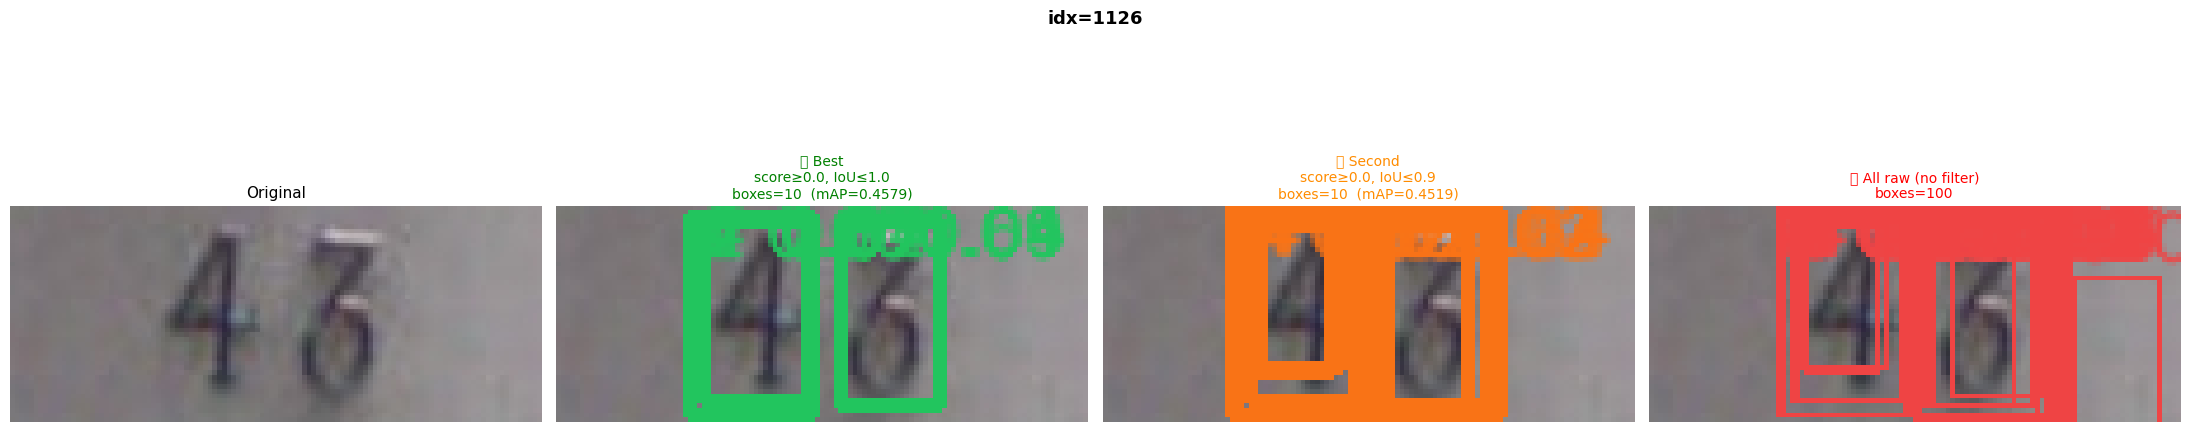


File: idx=1126
[Best]   score≥0.0, IoU≤1.0  → 10 boxes
  3  score=0.636  box=[60.5, 3.7, 81.4, 42.3]
  4  score=0.620  box=[31.2, 3.7, 53.9, 41.6]
  5  score=0.092  box=[60.5, 3.7, 81.4, 42.3]
  1  score=0.071  box=[31.2, 3.7, 53.9, 41.6]
  7  score=0.067  box=[31.2, 3.7, 53.9, 41.6]
  6  score=0.054  box=[60.5, 3.7, 81.4, 42.3]
  4  score=0.050  box=[28.6, 2.0, 54.3, 44.7]
  1  score=0.046  box=[28.6, 2.0, 54.3, 44.7]
  2  score=0.043  box=[31.2, 3.7, 53.9, 41.6]
  8  score=0.038  box=[60.5, 3.7, 81.4, 42.3]
[Second] score≥0.0, IoU≤0.9  → 10 boxes
  3  score=0.636  box=[60.5, 3.7, 81.4, 42.3]
  4  score=0.620  box=[31.2, 3.7, 53.9, 41.6]
  4  score=0.050  box=[28.6, 2.0, 54.3, 44.7]
  7  score=0.038  box=[59.5, 3.9, 77.4, 42.7]
  6  score=0.030  box=[57.2, 1.0, 84.6, 44.9]
  4  score=0.027  box=[32.4, 4.4, 50.1, 34.3]
  4  score=0.019  box=[27.3, 0.8, 56.4, 44.7]
  5  score=0.019  box=[58.7, 4.6, 81.8, 42.2]
  6  score=0.017  box=[57.8, 2.2, 82.4, 44.1]
  4  score=0.017  box=[33.0, 4

In [ ]:
# =========================================================
# 12. （選用）在 Validation 圖上跑視覺化，確認 mAP 視覺效果
# =========================================================
visualize_4panel(
    dataset=val_dataset,
    model=model,
    image_processor=image_processor,
    best_score=BEST_SCORE_THRESH,
    best_iou=BEST_IOU_THRESH,
    second_score=SECOND_SCORE_THRESH,
    second_iou=SECOND_IOU_THRESH,
    topk=TOPK_FIXED,
    num=VIS_NUM,
)